# Import and Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120

# Load dataset (semi-colon separated based on description)
df = pd.read_csv('data_set.csv', sep=',')

# Convert time_settled to datetime
df['time_settled'] = pd.to_datetime(df['time_settled'])

# Extract Month-Year period for monthly aggregation
df['year_month'] = df['time_settled'].dt.to_period('M')

print(f"Dataset Loaded Successfully! Total Rows: {len(df):,}")

Dataset Loaded Successfully! Total Rows: 587,303


# Overall Stake Analysis

In [12]:
# Global Metrics Calculation
total_volume = df['movement_amount_euros'].sum()
total_tx_count = len(df)

fraud_df = df[df['is_fraud'] == 1]
legit_df = df[df['is_fraud'] == 0]

fraud_loss = fraud_df['movement_amount_euros'].sum()
fraud_tx_count = len(fraud_df)

fraud_rate_count = (fraud_tx_count / total_tx_count) * 100
fraud_rate_amount = (fraud_loss / total_volume) * 100

avg_fraud_tx = fraud_df['movement_amount_euros'].mean()
avg_legit_tx = legit_df['movement_amount_euros'].mean()

# Print Summary for Slides
print("="*50)
print("             OVERALL STAKES SUMMARY              ")
print("="*50)
print(f"Total Transactions     : {total_tx_count:,}")
print(f"Total Volume Processed : €{total_volume:,.2f}")
print(f"Fraud Losses (Amount)  : €{fraud_loss:,.2f} ({fraud_rate_amount:.2f}% of total volume)")
print(f"Fraud Count            : {fraud_tx_count:,} ({fraud_rate_count:.2f}% of total count)")
print(f"Average Fraud Tx Size  : €{avg_fraud_tx:.2f}")
print(f"Average Legit Tx Size  : €{avg_legit_tx:.2f}")
print("="*50)

             OVERALL STAKES SUMMARY              
Total Transactions     : 587,303
Total Volume Processed : €154,084,657.19
Fraud Losses (Amount)  : €815,177.24 (0.53% of total volume)
Fraud Count            : 1,392 (0.24% of total count)
Average Fraud Tx Size  : €585.62
Average Legit Tx Size  : €261.59


# Monthly Evolution Analysis

In [13]:
# Group by month
monthly_df = df.groupby('year_month').agg(
    total_tx=('card_transaction_id', 'count'),
    fraud_tx=('is_fraud', 'sum'),
    total_amount=('movement_amount_euros', 'sum'),
    fraud_amount=('movement_amount_euros', lambda x: x[df.loc[x.index, 'is_fraud'] == 1].sum())
).reset_index()

# Convert Period to string for plotting
monthly_df['year_month_str'] = monthly_df['year_month'].astype(str)

# Calculate rates (%)
monthly_df['fraud_count_rate_%'] = (monthly_df['fraud_tx'] / monthly_df['total_tx']) * 100
monthly_df['fraud_loss_rate_%'] = (monthly_df['fraud_amount'] / monthly_df['total_amount']) * 100

# Monthly Evolution Plots

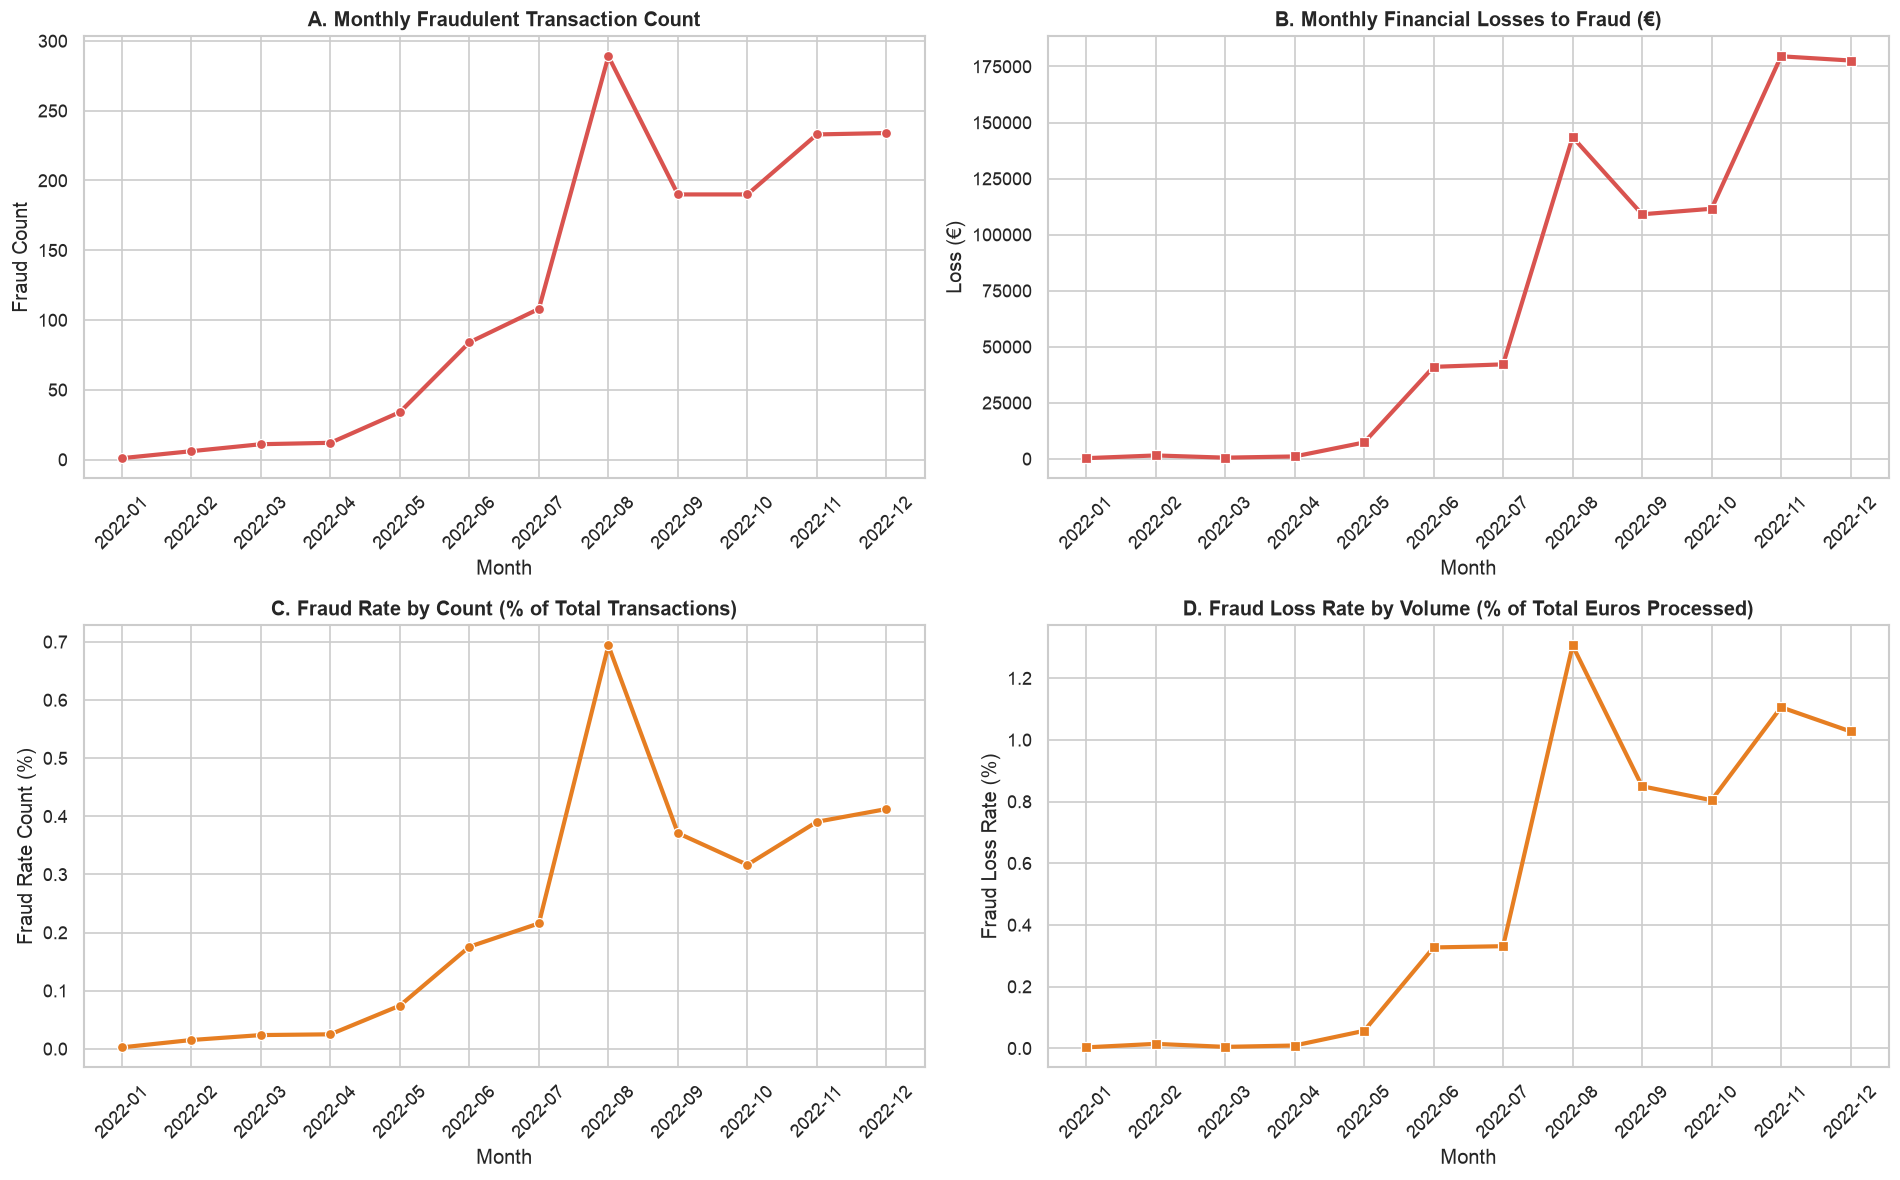

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Monthly Fraud Count
sns.lineplot(data=monthly_df, x='year_month_str', y='fraud_tx', ax=axes[0, 0], marker='o', color='#d9534f', linewidth=2.5)
axes[0, 0].set_title('A. Monthly Fraudulent Transaction Count', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Fraud Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Monthly Fraud Loss (€)
sns.lineplot(data=monthly_df, x='year_month_str', y='fraud_amount', ax=axes[0, 1], marker='s', color='#d9534f', linewidth=2.5)
axes[0, 1].set_title('B. Monthly Financial Losses to Fraud (€)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Loss (€)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Monthly Fraud Count Rate (%)
sns.lineplot(data=monthly_df, x='year_month_str', y='fraud_count_rate_%', ax=axes[1, 0], marker='o', color='#e67e22', linewidth=2.5)
axes[1, 0].set_title('C. Fraud Rate by Count (% of Total Transactions)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Fraud Rate Count (%)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Monthly Fraud Loss Rate (%)
sns.lineplot(data=monthly_df, x='year_month_str', y='fraud_loss_rate_%', ax=axes[1, 1], marker='s', color='#e67e22', linewidth=2.5)
axes[1, 1].set_title('D. Fraud Loss Rate by Volume (% of Total Euros Processed)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Fraud Loss Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Monthly average transaction mount

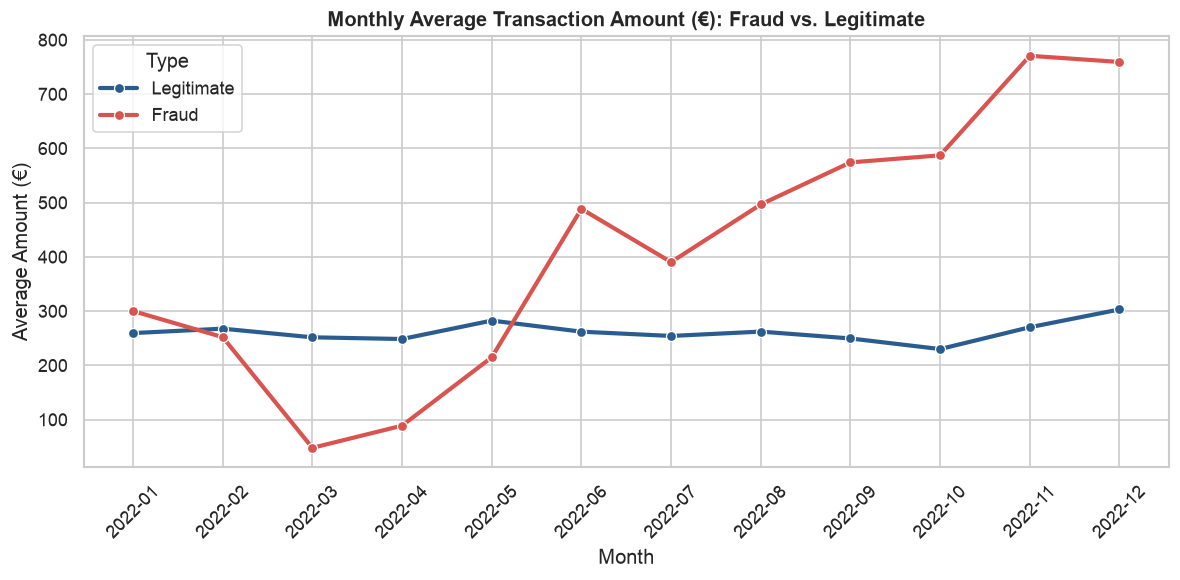

In [15]:
# Calculate monthly average ticket size
monthly_avg_df = df.groupby(['year_month', 'is_fraud']).agg(
    avg_amount=('movement_amount_euros', 'mean')
).reset_index()

monthly_avg_df['year_month_str'] = monthly_avg_df['year_month'].astype(str)

# Map is_fraud to readable labels
monthly_avg_df['Transaction Type'] = monthly_avg_df['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})

# Plotting Monthly Average Transaction Size
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_avg_df, 
    x='year_month_str', 
    y='avg_amount', 
    hue='Transaction Type',
    palette=['#2b5c8f', '#d9534f'],
    marker='o', 
    linewidth=2.5
)

plt.title('Monthly Average Transaction Amount (€): Fraud vs. Legitimate', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Amount (€)')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

# Question 2 a

In [20]:
# ==========================================
# QUESTION 2A: EXPERT RULE DISCOVERY & EVALUATION
# ==========================================

# Total benchmark counts
total_frauds = df['is_fraud'].sum()
total_tx = len(df)
num_weeks = (df['time_settled'].max() - df['time_settled'].min()).days / 7

def evaluate_rule(df, rule_condition, rule_name="Expert Rule"):
    alerts = df[rule_condition]
    tp = alerts['is_fraud'].sum()
    fp = len(alerts) - tp
    
    precision = (tp / len(alerts)) * 100 if len(alerts) > 0 else 0
    recall = (tp / total_frauds) * 100
    alerts_per_week = len(alerts) / num_weeks
    
    print(f"=== {rule_name.upper()} ===")
    print(f"Rule Condition         : {rule_condition.name if hasattr(rule_condition, 'name') else 'Custom Condition'}")
    print(f"Total Alerts           : {len(alerts):,} ({len(alerts)/total_tx*100:.2f}% of all tx)")
    print(f"Alerts / Week          : {alerts_per_week:.1f}")
    print(f"Frauds Caught (TP)     : {tp:,} / {total_frauds:,}")
    print(f"Precision              : {precision:.2f}%")
    print(f"Recall                 : {recall:.2f}% (Target: >= 30%)")
    print("="*45)
    return precision, recall, alerts_per_week

# --- 1. SCANNING CANDIDATE FEATURES FOR >= 30% RECALL ---
print("--- BIVARIATE SCAN (RECALL BY CATEGORY) ---")

# Scan reading_method_group_name
for cat in df['reading_method_group_name'].dropna().unique():
    subset_fraud = df[(df['reading_method_group_name'] == cat) & (df['is_fraud'] == 1)]
    rec = (len(subset_fraud) / total_frauds) * 100
    if rec >= 25: # Display top candidates near or above 30%
        print(f"Feature: reading_method_group_name == '{cat}' -> Recall: {rec:.1f}%")

# Scan counterparty_country_code (Cross-Border)
df['is_cross_border'] = (df['legal_country'] != df['counterparty_country_code']).astype(int)
rec_cb = (df[(df['is_cross_border'] == 1) & (df['is_fraud'] == 1)].shape[0] / total_frauds) * 100
print(f"Feature: is_cross_border == 1 -> Recall: {rec_cb:.1f}%")

# Scan Virtual vs Physical
rec_virt = (df[(df['is_physical'] == 0) & (df['is_fraud'] == 1)].shape[0] / total_frauds) * 100
print(f"Feature: is_physical == 0 (Virtual Card) -> Recall: {rec_virt:.1f}%")

print("\n" + "="*45 + "\n")

# --- 2. DEFINE & EVALUATE YOUR EXPERT RULE ---
# Replace 'ONLINE' below with whichever top category/condition hit >= 30% recall in your scan above!
# Example Rule 1: High-risk reading method (e.g. online / e-commerce)
rule_1_condition = (df['reading_method_group_name'] == 'VAD') # Adjust value to match your CSV

# Example Rule 2: Bivariate Rule (e.g. Virtual Card OR Cross-Border with high velocity)
# rule_2_condition = (df['is_physical'] == 0) & (df['movement_amount_euros'] > 50)

# Run evaluation
evaluate_rule(df, rule_1_condition, rule_name="Expert Rule 1 (Primary Category)")

--- BIVARIATE SCAN (RECALL BY CATEGORY) ---
Feature: reading_method_group_name == 'VAD' -> Recall: 96.7%
Feature: is_cross_border == 1 -> Recall: 99.8%
Feature: is_physical == 0 (Virtual Card) -> Recall: 15.7%


=== EXPERT RULE 1 (PRIMARY CATEGORY) ===
Rule Condition         : reading_method_group_name
Total Alerts           : 559,597 (95.28% of all tx)
Alerts / Week          : 10761.5
Frauds Caught (TP)     : 1,346 / 1,392
Precision              : 0.24%
Recall                 : 96.70% (Target: >= 30%)


(np.float64(0.2405302387253684),
 np.float64(96.69540229885058),
 10761.48076923077)

In [21]:
# ==========================================
# FAST BIVARIATE RECALL SCAN FOR EXPERT RULE
# ==========================================

total_frauds = df['is_fraud'].sum()

print("--- 1. CATEGICAL FEATURES RECALL SCAN ---")
cat_cols = ['payment_method', 'reading_method_group_name', 'is_physical', 
            'member_role', 'price_plan_subgroup_at_time']

for col in cat_cols:
    if col in df.columns:
        stats = df.groupby(col).agg(
            total_tx=('is_fraud', 'count'),
            fraud_tx=('is_fraud', 'sum')
        )
        stats['recall_%'] = (stats['fraud_tx'] / total_frauds) * 100
        stats['precision_%'] = (stats['fraud_tx'] / stats['total_tx']) * 100
        
        # Display values catching >= 15% of total frauds
        top_val = stats[stats['recall_%'] >= 15].sort_values(by='recall_%', ascending=False)
        if not top_val.empty:
            print(f"\nFeature: {col}")
            print(top_val[['total_tx', 'fraud_tx', 'recall_%', 'precision_%']].round(2))

print("\n" + "="*50 + "\n")

print("--- 2. CROSS-BORDER RECALL SCAN ---")
df['is_cross_border'] = (df['legal_country'] != df['counterparty_country_code']).astype(int)
cb_stats = df.groupby('is_cross_border').agg(
    total_tx=('is_fraud', 'count'),
    fraud_tx=('is_fraud', 'sum')
)
cb_stats['recall_%'] = (cb_stats['fraud_tx'] / total_frauds) * 100
cb_stats['precision_%'] = (cb_stats['fraud_tx'] / cb_stats['total_tx']) * 100
print(cb_stats.round(2))

print("\n" + "="*50 + "\n")

print("--- 3. NUMERICAL THRESHOLD SCAN (AMOUNT & VELOCITY) ---")
# Testing simple intuitive thresholds
for amt in [50, 100, 200, 500]:
    cnt = df[(df['movement_amount_euros'] > amt) & (df['is_fraud'] == 1)].shape[0]
    rec = (cnt / total_frauds) * 100
    prec = (cnt / df[df['movement_amount_euros'] > amt].shape[0]) * 100 if df[df['movement_amount_euros'] > amt].shape[0] > 0 else 0
    print(f"Amount > €{amt:<3} -> Recall: {rec:.1f}% | Precision: {prec:.2f}%")

--- 1. CATEGICAL FEATURES RECALL SCAN ---

Feature: payment_method
                total_tx  fraud_tx  recall_%  precision_%
payment_method                                           
online            559597      1346      96.7         0.24

Feature: reading_method_group_name
                           total_tx  fraud_tx  recall_%  precision_%
reading_method_group_name                                           
VAD                          559597      1346      96.7         0.24

Feature: is_physical
             total_tx  fraud_tx  recall_%  precision_%
is_physical                                           
True           338658      1173     84.27         0.35
False          248645       219     15.73         0.09

Feature: member_role
             total_tx  fraud_tx  recall_%  precision_%
member_role                                           
owner          485142      1235     88.72         0.25

Feature: price_plan_subgroup_at_time
                             total_tx  fraud_tx  

In [22]:
# ==========================================
# QUESTION 2A: MULTI-VARIABLE EXPERT RULES
# ==========================================

# Make sure cross-border flag exists
df['is_cross_border'] = (df['legal_country'] != df['counterparty_country_code']).astype(int)

# --- CANDIDATE RULE 1: Online + High Amount (€500+) ---
# Strategy: Focus on severe losses
rule_1 = (df['reading_method_group_name'] == 'VAD') & (df['movement_amount_euros'] > 500)

# --- CANDIDATE RULE 2: Online + Cross-Border + High Amount (€200+) ---
# Strategy: Broad coverage on high-ticket cross-border online payments
rule_2 = (df['reading_method_group_name'] == 'VAD') & (df['is_cross_border'] == 1) & (df['movement_amount_euros'] > 200)

# --- CANDIDATE RULE 3: Solo Basic Plan + Online Payment + Amount > €100 ---
# Strategy: Target top price plan vector (Solo Basic accounts for ~40% of fraud)
rule_3 = (df['price_plan_subgroup_at_time'] == 'solo_basic') & (df['reading_method_group_name'] == 'VAD') & (df['movement_amount_euros'] > 100)

# --- CANDIDATE RULE 4: High Velocity Burst + Online Payment ---
# Strategy: Catch fast consecutive payments (time_settled_diff < 120s)
rule_4 = (df['reading_method_group_name'] == 'VAD') & (df['time_settled_diff'] < 120) & (df['movement_amount_euros'] > 50)


# Run evaluation across all candidates
print("--------------------------------------------------")
evaluate_rule(df, rule_1, rule_name="Rule 1: VAD & Amount > €500")
print("--------------------------------------------------")
evaluate_rule(df, rule_2, rule_name="Rule 2: VAD & Cross-Border & Amount > €200")
print("--------------------------------------------------")
evaluate_rule(df, rule_3, rule_name="Rule 3: Solo Basic & VAD & Amount > €100")
print("--------------------------------------------------")
evaluate_rule(df, rule_4, rule_name="Rule 4: Velocity Burst (<2 min) & VAD")
print("--------------------------------------------------")

--------------------------------------------------
=== RULE 1: VAD & AMOUNT > €500 ===
Rule Condition         : None
Total Alerts           : 90,440 (15.40% of all tx)
Alerts / Week          : 1739.2
Frauds Caught (TP)     : 786 / 1,392
Precision              : 0.87%
Recall                 : 56.47% (Target: >= 30%)
--------------------------------------------------
=== RULE 2: VAD & CROSS-BORDER & AMOUNT > €200 ===
Rule Condition         : None
Total Alerts           : 205,504 (34.99% of all tx)
Alerts / Week          : 3952.0
Frauds Caught (TP)     : 1,065 / 1,392
Precision              : 0.52%
Recall                 : 76.51% (Target: >= 30%)
--------------------------------------------------
=== RULE 3: SOLO BASIC & VAD & AMOUNT > €100 ===
Rule Condition         : None
Total Alerts           : 48,696 (8.29% of all tx)
Alerts / Week          : 936.5
Frauds Caught (TP)     : 470 / 1,392
Precision              : 0.97%
Recall                 : 33.76% (Target: >= 30%)
--------------------

# Testing that data_set and test are the same

In [42]:
# Check if the files are identical
print(f"data_set.csv shape : {pd.read_csv('data_set.csv', sep=';').shape}")
print(f"test.csv shape     : {pd.read_csv('test.csv', sep=';').shape}")

# Check duplicate transaction IDs across both files
df_data = pd.read_csv('data_set.csv', sep=',')
df_test = pd.read_csv('test.csv', sep=',')

overlap = df_data['card_transaction_id'].isin(df_test['card_transaction_id']).sum()
print(f"Overlapping transaction IDs: {overlap:,} out of {len(df_data):,}")

data_set.csv shape : (587303, 1)
test.csv shape     : (587303, 1)
Overlapping transaction IDs: 587,303 out of 587,303


# Machine Learning model

### 1. Preprocessing

In [43]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_auc_score

# 1. Load data
df_full = pd.read_csv('data_set.csv', sep=',')
df_full['time_settled'] = pd.to_datetime(df_full['time_settled'])

# Feature Engineering
df_full['hour'] = df_full['time_settled'].dt.hour
df_full['dayofweek'] = df_full['time_settled'].dt.dayofweek
df_full['is_weekend'] = df_full['dayofweek'].isin([5, 6]).astype(int)
df_full['is_cross_border'] = (df_full['legal_country'] != df_full['counterparty_country_code']).astype(int)

# One-Hot Encoding
cat_cols = ['member_role', 'price_plan_subgroup_at_time', 'card_level_name', 
            'payment_method', 'reading_method_group_name', 'local_amount_currency']

df_encoded = pd.get_dummies(df_full, columns=cat_cols, drop_first=True)

# Define Features and Target
exclude_cols = ['card_transaction_id', 'card_id', 'time_settled', 'legal_country', 
                'counterparty_country_code', 'year_month', 'year_month_str', 'is_fraud']

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['is_fraud'].astype(int)

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Get corresponding raw metadata for test set (for Rule 4 evaluation)
test_indices = y_test.index
df_test = df_full.loc[test_indices]

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")

Train size: 469,842 | Test size: 117,461


In [44]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    eval_metric='aucpr',
    random_state=42
)

model.fit(X_train, y_train)

# Predict probabilities on HELD-OUT test set
y_probs_test = model.predict_proba(X_test)[:, 1]

# Find probability threshold for ~35% Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_test)
target_recall = 0.35
idx = np.where(recalls >= target_recall)[0][-1]
opt_threshold = thresholds[idx]

y_pred_test = (y_probs_test >= opt_threshold).astype(int)

# Evaluation Metrics
tp_ml = sum((y_pred_test == 1) & (y_test == 1))
fp_ml = sum((y_pred_test == 1) & (y_test == 0))
total_test_frauds = sum(y_test)

prec_ml = (tp_ml / (tp_ml + fp_ml)) * 100 if (tp_ml + fp_ml) > 0 else 0
rec_ml = (tp_ml / total_test_frauds) * 100

num_weeks_test = max((df_test['time_settled'].max() - df_test['time_settled'].min()).days / 7, 1)
alerts_per_week_ml = (tp_ml + fp_ml) / num_weeks_test

print("="*50)
print(f"=== XGBOOST MODEL ON HELD-OUT 20% TEST SET (Threshold: {opt_threshold:.4f}) ===")
print("="*50)
print(f"Test Set Frauds Caught : {tp_ml} / {total_test_frauds}")
print(f"Model Recall           : {rec_ml:.2f}%")
print(f"Model Precision        : {prec_ml:.2f}%")
print(f"Weekly Alert Volume    : {alerts_per_week_ml:.1f}")
print("="*50)

=== XGBOOST MODEL ON HELD-OUT 20% TEST SET (Threshold: 0.9968) ===
Test Set Frauds Caught : 98 / 278
Model Recall           : 35.25%
Model Precision        : 100.00%
Weekly Alert Volume    : 1.9


In [47]:
# 3. Evaluate Rule 4 on HELD-OUT 20% Test Set & Build Comparison Benchmark
rule_4_test_cond = (df_test['reading_method_group_name'] == 'VAD') & (df_test['time_settled_diff'] < 120) & (df_test['movement_amount_euros'] > 50)
rule_alerts_test = df_test[rule_4_test_cond]

tp_rule = rule_alerts_test['is_fraud'].sum()
fp_rule = len(rule_alerts_test) - tp_rule
fn_rule = total_test_frauds - tp_rule  # Frauds missed

prec_rule = (tp_rule / len(rule_alerts_test)) * 100 if len(rule_alerts_test) > 0 else 0
rec_rule = (tp_rule / total_test_frauds) * 100
alerts_per_week_rule = len(rule_alerts_test) / num_weeks_test

# ML Model False Negatives
fn_ml = total_test_frauds - tp_ml

# Build Comparison Table
comparison_test_df = pd.DataFrame({
    'Metric': [
        'Recall (%)', 
        'Precision (%)', 
        'Weekly Alert Volume', 
        'False Positive Count (Legit Flagged)', 
        'False Negative Count (Frauds Missed)'
    ],
    'Expert Rule (Rule 4)': [
        f"{rec_rule:.2f}%", 
        f"{prec_rule:.2f}%", 
        f"{alerts_per_week_rule:.1f}", 
        f"{fp_rule:,}", 
        f"{fn_rule:,}"
    ],
    'ML Model (XGBoost)': [
        f"{rec_ml:.2f}%", 
        f"{prec_ml:.2f}%", 
        f"{alerts_per_week_ml:.1f}", 
        f"{fp_ml:,}", 
        f"{fn_ml:,}"
    ]
})

print("\n=== REAL DEFENSE BENCHMARK (20% HELD-OUT TEST SET) ===")
comparison_test_df


=== REAL DEFENSE BENCHMARK (20% HELD-OUT TEST SET) ===


,Metric,Expert Rule (Rule 4),ML Model (XGBoost)
0,Recall (%),39.93%,35.25%
1,Precision (%),1.86%,100.00%
2,Weekly Alert Volume,114.7,1.9
3,False Positive Count (Legit Flagged),"5,851",0
4,False Negative Count (Frauds Missed),167,180


/var/folders/fz/wq3679m55ljbqt9g587mqbph0000gn/T/ipykernel_11322/2179307905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


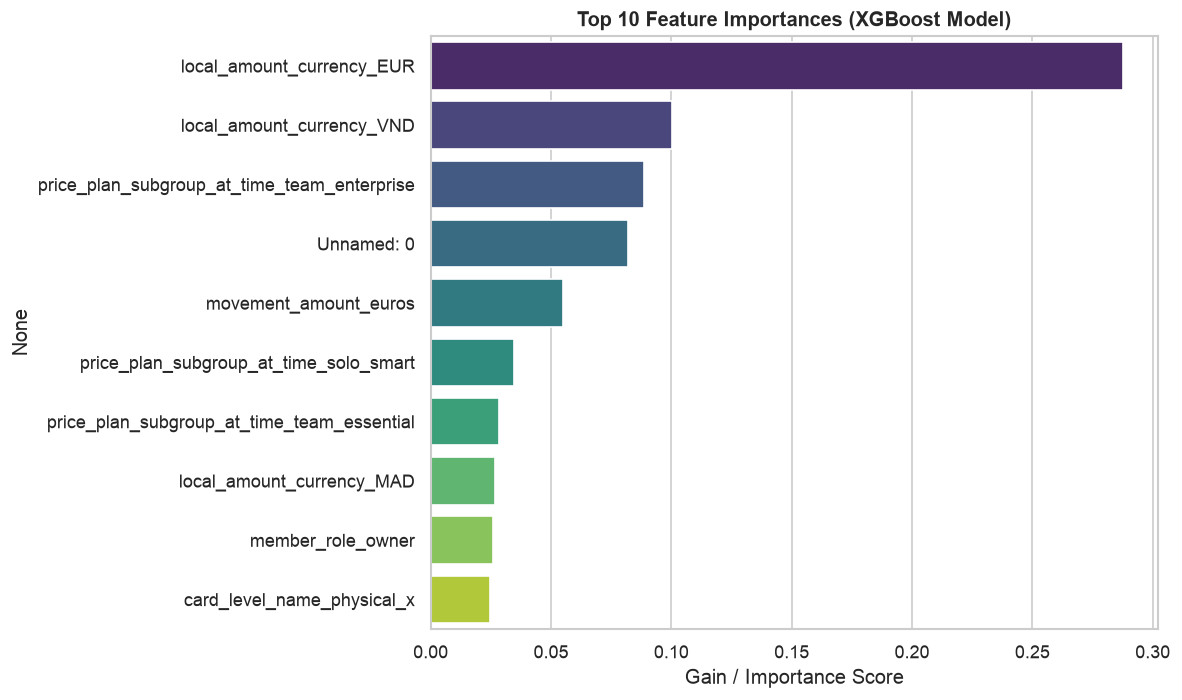

In [46]:
# Top 10 Feature Importances
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost Model)', fontsize=12, fontweight='bold')
plt.xlabel('Gain / Importance Score')
plt.tight_layout()
plt.show()